# N5 — FF49 Baseline Peer Lists (M0)

Builds the M0 baseline peer lists using Fama-French 49 industry classification.
All firms in the same FF49 industry and same fyear are assigned as peers with
equal weight (similarity_score = 1.0, rank = 1 for all).

This is the direct methodological equivalent of how analysts use industry
classifications in practice — every firm in the same industry is a valid peer.

**Design decisions:**
- Peers restricted to same fyear (consistent with M1/M2/M3)
- All industry peers receive equal weight: similarity_score = 1.0, rank = 1
- No kNN — M0 is purely membership-based
- k varies by industry size (Banking ~50+, Tobacco ~5) — this is intentional

**Input:** `panel_clean.parquet` (N1)
**Output:** `peers_m0.parquet` — schema: `focal_tic | focal_fyear | peer_tic | rank | similarity_score | model`


In [1]:
# Cell 1 — imports & config
import sys; sys.path.insert(0, '..')
from config import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Config loaded.")
print(f"  PANEL_CLEAN : {PANEL_CLEAN}")
print(f"  PEERS_M0    : {PEERS_M0}")
print(f"  YEARS       : {YEARS}")


Config loaded.
  PANEL_CLEAN : /work/Repo/notebooks/../data/processed/panel_clean.parquet
  PEERS_M0    : /work/Repo/notebooks/../data/results/peers_m0.parquet
  YEARS       : [2020, 2021, 2022, 2023, 2024]


In [2]:
# Cell 2 — declare I/O
INPUTS  = [PANEL_CLEAN]
OUTPUTS = [PEERS_M0]
# PURPOSE : Build M0 FF49 baseline peer lists — all same-industry firms per fyear
# RUNTIME : ~2 min
# DEPENDS : panel_clean.parquet (N1)


## 1. Load Panel

In [3]:
# Cell 3 — load panel and restrict to evaluation sample
df_full = pd.read_parquet(PANEL_CLEAN, columns=[
    'gvkey', 'tic', 'fyear', 'ff49_num', 'ff49_abbr', 'industry'
])
print(f"Full panel: {df_full.shape[0]:,} rows | {df_full['tic'].nunique():,} unique tickers")

# Build evaluation sample — firms with valid Gemini summaries
INVALID_FLAGS = {'ERROR', 'INSUFFICIENT_DATA', 'ERROR_EXTRACTING_TEXT'}
eval_tickers = set()
for yr in YEARS:
    path = SUMMARIES_FILES[yr]
    if not path.exists():
        print(f"  WARNING: {path} not found")
        continue
    df_s = pd.read_csv(path)
    valid = df_s[
        df_s['business_description'].notna() &
        ~df_s['business_description'].isin(INVALID_FLAGS) &
        (df_s['business_description'].str.len() > 50)
    ]
    for _, row in valid.iterrows():
        eval_tickers.add((row['tic'], int(row['fyear'])))

print(f"Evaluation sample: {len(eval_tickers):,} firm-years | "
      f"{len(set(t for t, _ in eval_tickers)):,} unique tickers")

# Restrict panel to evaluation sample only
df = df_full[
    df_full.apply(lambda r: (r['tic'], int(r['fyear'])) in eval_tickers, axis=1)
].copy()

print(f"Restricted panel : {df.shape[0]:,} rows | {df['tic'].nunique():,} unique tickers")
print(f"Years            : {sorted(df['fyear'].unique())}")

Full panel: 20,883 rows | 5,699 unique tickers
Evaluation sample: 13,559 firm-years | 3,494 unique tickers
Restricted panel : 13,559 rows | 3,494 unique tickers
Years            : [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


## 2. Industry Size Distribution

Understanding the peer group sizes is important for interpreting M0 results.
Large industries (Banking, Trading) will have many peers; small industries
(Tobacco, Coal) will have very few. This variability is a known limitation
of the FF49 baseline.


In [4]:
# Cell 4 — industry size distribution per fyear
print("Peer group sizes by industry (averaged across years):")
print()

sizes = (df.groupby(['fyear', 'ff49_num', 'industry'])['tic']
           .count()
           .reset_index()
           .rename(columns={'tic': 'n_peers'}))

avg_sizes = (sizes.groupby(['ff49_num', 'industry'])['n_peers']
                  .agg(['mean', 'min', 'max'])
                  .reset_index()
                  .sort_values('mean', ascending=False))

print(avg_sizes.to_string(index=False))
print()
print(f"Overall: mean={sizes['n_peers'].mean():.0f} peers | "
      f"min={sizes['n_peers'].min()} | max={sizes['n_peers'].max()}")


Peer group sizes by industry (averaged across years):

 ff49_num                    industry  mean  min  max
       45                     Banking 301.2  267  325
       48                     Trading 283.2  257  297
       13     Pharmaceutical Products 223.8  194  268
       36           Computer Software 220.4  180  243
       34           Business Services 120.0   99  135
       37        Electronic Equipment 110.4  103  119
       43                      Retail 108.8   96  113
       46                   Insurance  95.0   87  106
       12           Medical Equipment  93.2   84  103
       21                   Machinery  82.4   78   85
       30   Petroleum and Natural Gas  78.8   57   95
       42                   Wholesale  72.2   67   77
       31                   Utilities  71.4   64   77
       41              Transportation  61.2   55   65
       14                   Chemicals  57.8   54   59
       11                  Healthcare  45.2   36   52
       17      Construction

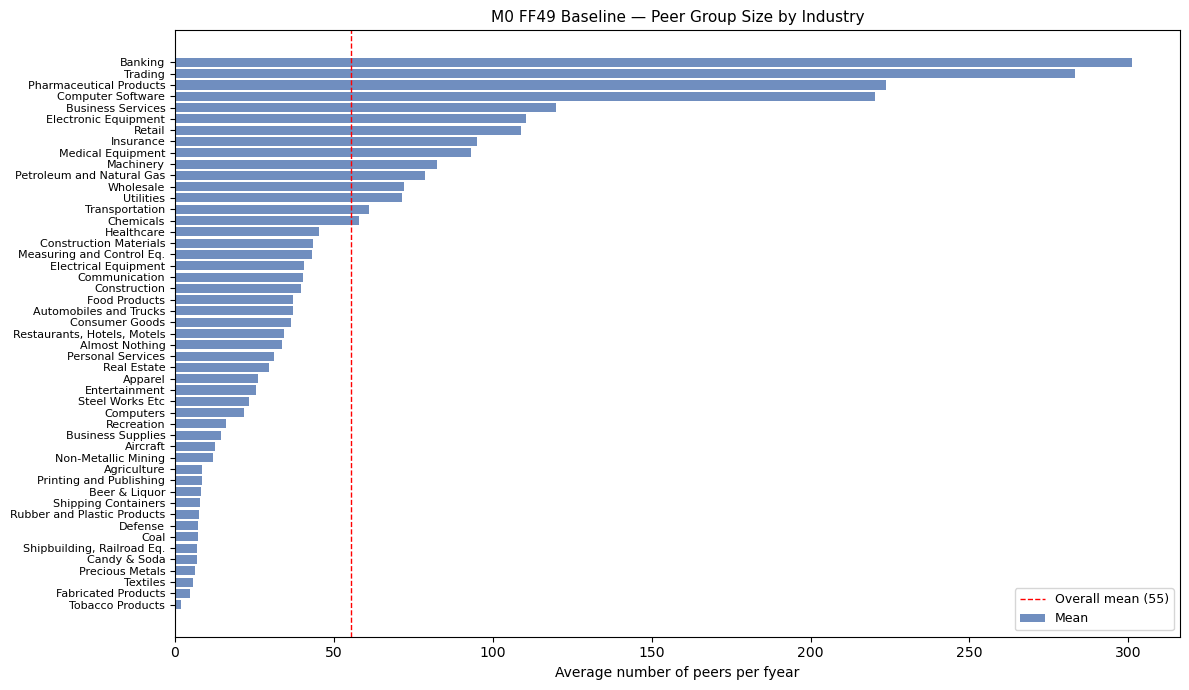

Saved: /work/Repo/notebooks/../figures/n5_m0_industry_sizes.pdf


In [5]:
# Cell 5 — visualise industry size distribution
fig, ax = plt.subplots(figsize=(12, 7))

avg_plot = avg_sizes.sort_values('mean', ascending=True)
y_pos = range(len(avg_plot))

ax.barh(y_pos, avg_plot['mean'], color='#4C72B0', alpha=0.8, label='Mean')
ax.set_yticks(y_pos)
ax.set_yticklabels(avg_plot['industry'], fontsize=8)
ax.set_xlabel("Average number of peers per fyear")
ax.set_title("M0 FF49 Baseline — Peer Group Size by Industry", fontsize=11)
ax.axvline(avg_plot['mean'].mean(), color='red', linewidth=1,
           linestyle='--', label=f"Overall mean ({avg_plot['mean'].mean():.0f})")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES / "n5_m0_industry_sizes.pdf", dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES / 'n5_m0_industry_sizes.pdf'}")


## 3. Build M0 Peer Lists

For each focal firm, all other firms in the same FF49 industry and same fyear
are assigned as peers with equal weight (similarity_score = 1.0, rank = 1).


In [6]:
# Cell 6 — build M0 peer lists
print("Building M0 FF49 baseline peer lists...")
print()

all_peers = []

for yr in YEARS:
    df_year = df[df['fyear'] == yr].dropna(subset=['tic']).copy()
    n_firms = len(df_year)
    records = []

    # Group by FF49 industry
    for ff49_num, group in df_year.groupby('ff49_num'):
        tickers = group['tic'].values
        n_peers = len(tickers)

        if n_peers < 2:
            # Only one firm in this industry-year — no peers possible
            continue

        for focal_tic in tickers:
            # All other firms in same industry = peers
            peer_tickers = tickers[tickers != focal_tic]
            for peer_tic in peer_tickers:
                records.append({
                    'focal_tic'       : focal_tic,
                    'focal_fyear'     : yr,
                    'peer_tic'        : peer_tic,
                    'rank'            : 1,          # equal weight — all rank 1
                    'similarity_score': 1.0,        # equal weight
                    'model'           : 'M0_FF49',
                })

    peers_yr = pd.DataFrame(records)
    all_peers.append(peers_yr)

    n_records = len(peers_yr)
    avg_peers = n_records / n_firms if n_firms > 0 else 0
    print(f"  {yr}: {n_firms:,} firms → {n_records:,} peer records "
          f"(avg {avg_peers:.0f} peers per firm)")

peers_m0 = pd.concat(all_peers, ignore_index=True)
print()
print(f"Total peer records: {len(peers_m0):,}")


Building M0 FF49 baseline peer lists...

  2020: 2,446 firms → 312,734 peer records (avg 128 peers per firm)
  2021: 2,781 firms → 392,072 peer records (avg 141 peers per firm)
  2022: 2,717 firms → 383,490 peer records (avg 141 peers per firm)
  2023: 2,742 firms → 386,462 peer records (avg 141 peers per firm)
  2024: 2,873 firms → 419,876 peer records (avg 146 peers per firm)

Total peer records: 1,894,634


## 4. Validation

In [7]:
# Cell 7 — schema validation
print("Schema check:")
for col in PEER_SCHEMA:
    present = col in peers_m0.columns
    dtype   = peers_m0[col].dtype if present else "MISSING"
    print(f"  {col:<20} {'✓' if present else '✗'}  {dtype}")

print()
print("Null check:")
print(peers_m0.isnull().sum().to_string())

print()
# Verify rank is always 1
assert (peers_m0['rank'] == 1).all(), "ERROR: rank should be 1 for all M0 peers"
assert (peers_m0['similarity_score'] == 1.0).all(), "ERROR: similarity_score should be 1.0"
assert (peers_m0['model'] == 'M0_FF49').all(), "ERROR: model label incorrect"
print("All assertions passed ✓")
print(f"  rank == 1 for all records")
print(f"  similarity_score == 1.0 for all records")
print(f"  model == 'M0_FF49' for all records")


Schema check:
  focal_tic            ✓  object
  focal_fyear          ✓  int64
  peer_tic             ✓  object
  rank                 ✓  int64
  similarity_score     ✓  float64
  model                ✓  object

Null check:
focal_tic           0
focal_fyear         0
peer_tic            0
rank                0
similarity_score    0
model               0

All assertions passed ✓
  rank == 1 for all records
  similarity_score == 1.0 for all records
  model == 'M0_FF49' for all records


In [8]:
# Cell 8 — peer count distribution
peer_counts = (peers_m0.groupby(['focal_tic', 'focal_fyear'])['peer_tic']
                        .count()
                        .reset_index()
                        .rename(columns={'peer_tic': 'n_peers'}))

print("Peer count distribution across focal firm-years:")
print(f"  Mean    : {peer_counts['n_peers'].mean():.1f}")
print(f"  Median  : {peer_counts['n_peers'].median():.0f}")
print(f"  Min     : {peer_counts['n_peers'].min()}")
print(f"  Max     : {peer_counts['n_peers'].max()}")
print(f"  Std     : {peer_counts['n_peers'].std():.1f}")
print()

# Firms with very few peers (potential concern for evaluation)
few_peers = peer_counts[peer_counts['n_peers'] < 5]
print(f"Firm-years with <5 peers: {len(few_peers):,} "
      f"({len(few_peers)/len(peer_counts)*100:.1f}%)")
if len(few_peers) > 0:
    print("  These will have high variance in MdAPE — flag in thesis")
    print(f"  Example industries: check ff49 groups with <5 firms")


Peer count distribution across focal firm-years:
  Mean    : 139.7
  Median  : 102
  Min     : 1
  Max     : 324
  Std     : 103.6

Firm-years with <5 peers: 45 (0.3%)
  These will have high variance in MdAPE — flag in thesis
  Example industries: check ff49 groups with <5 firms


In [9]:
# Cell 9 — spot check: verify peer symmetry
# If A is a peer of B, B must be a peer of A
print("Symmetry check (sample)...")
sample_focal = peers_m0['focal_tic'].iloc[0]
sample_year  = peers_m0['focal_fyear'].iloc[0]

focal_peers = set(peers_m0[
    (peers_m0['focal_tic'] == sample_focal) &
    (peers_m0['focal_fyear'] == sample_year)
]['peer_tic'])

# Check reciprocal
for peer in list(focal_peers)[:3]:
    peer_of_peer = set(peers_m0[
        (peers_m0['focal_tic'] == peer) &
        (peers_m0['focal_fyear'] == sample_year)
    ]['peer_tic'])
    assert sample_focal in peer_of_peer, f"Symmetry broken: {peer} → {sample_focal} missing"

print(f"  Symmetry verified for {sample_focal} (FY{sample_year}) ✓")
print(f"  Has {len(focal_peers)} industry peers")


Symmetry check (sample)...
  Symmetry verified for ALCO (FY2020) ✓
  Has 7 industry peers


## 5. Industry Coverage Diagnostics

In [10]:
# Cell 10 — firms with no peers (singleton industries)
all_focal = set(zip(df['tic'], df['fyear']))
has_peers = set(zip(peers_m0['focal_tic'], peers_m0['focal_fyear']))
no_peers  = all_focal - has_peers

print(f"Firm-years with NO peers (singleton in their industry-year): {len(no_peers):,}")
if no_peers:
    df_no_peers = pd.DataFrame(no_peers, columns=['tic', 'fyear'])
    df_no_peers = df_no_peers.merge(
        df[['tic', 'fyear', 'ff49_abbr', 'industry']], on=['tic', 'fyear'], how='left'
    )
    print()
    print(df_no_peers.groupby(['ff49_abbr', 'industry'])
                     .size()
                     .reset_index(name='count')
                     .sort_values('count', ascending=False)
                     .to_string(index=False))
    print()
    print("NOTE: These firm-years will be excluded from M0 evaluation in N9.")
    print("      They will still appear in M1/M2/M3 evaluation.")


Firm-years with NO peers (singleton in their industry-year): 1

ff49_abbr         industry  count
    Smoke Tobacco Products      1

NOTE: These firm-years will be excluded from M0 evaluation in N9.
      They will still appear in M1/M2/M3 evaluation.


## 6. Save

In [11]:
# Cell 11 — save peers_m0.parquet
PEERS_M0.parent.mkdir(parents=True, exist_ok=True)
peers_m0.to_parquet(PEERS_M0, index=False)

print(f"Saved : {PEERS_M0}")
print(f"Shape : {peers_m0.shape[0]:,} rows × {peers_m0.shape[1]} columns")
print()
print("Peer records per year:")
print(peers_m0.groupby('focal_fyear')['focal_tic'].count().to_string())
print()
print(f"Unique focal firms : {peers_m0['focal_tic'].nunique():,}")
print(f"Unique peer firms  : {peers_m0['peer_tic'].nunique():,}")


Saved : /work/Repo/notebooks/../data/results/peers_m0.parquet
Shape : 1,894,634 rows × 6 columns

Peer records per year:
focal_fyear
2020    312734
2021    392072
2022    383490
2023    386462
2024    419876

Unique focal firms : 3,494
Unique peer firms  : 3,494


In [12]:
# Cell 12 — final summary
print("=" * 60)
print("N5 COMPLETE — M0 FF49 BASELINE SUMMARY")
print("=" * 60)
print(f"  Model          : M0_FF49")
print(f"  Method         : FF49 industry membership")
print(f"  Peer weight    : Equal (rank=1, similarity=1.0 for all)")
print(f"  Scope          : Same fyear only")
print(f"  Years          : {YEARS}")
print(f"  Total records  : {len(peers_m0):,}")
print()
print(f"  Key design note:")
print(f"  Peer count varies by industry size — this is intentional.")
print(f"  In N9 evaluation, MdAPE is computed using ALL available")
print(f"  industry peers, not a fixed k. This matches how analysts")
print(f"  use industry classifications in practice.")
print(f"  (Bhojraj & Lee 2002)")
print()
print(f"  Output: {PEERS_M0}")
print()
print("  Next: Run N6 (M1 financial kNN) then N9 partial evaluation")


N5 COMPLETE — M0 FF49 BASELINE SUMMARY
  Model          : M0_FF49
  Method         : FF49 industry membership
  Peer weight    : Equal (rank=1, similarity=1.0 for all)
  Scope          : Same fyear only
  Years          : [2020, 2021, 2022, 2023, 2024]
  Total records  : 1,894,634

  Key design note:
  Peer count varies by industry size — this is intentional.
  In N9 evaluation, MdAPE is computed using ALL available
  industry peers, not a fixed k. This matches how analysts
  use industry classifications in practice.
  (Bhojraj & Lee 2002)

  Output: /work/Repo/notebooks/../data/results/peers_m0.parquet

  Next: Run N6 (M1 financial kNN) then N9 partial evaluation
